In [1]:
!pip install trafilatura pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import trafilatura
from urllib.parse import urlparse
from urllib.robotparser import RobotFileParser

articles = pd.read_csv("sosc314_week2_data.csv")
articles = articles.copy()

USER_AGENT = "SOSC314-academic-project/1.0"

def robots_allows(url):
    parsed = urlparse(url)
    robots_url = f"{parsed.scheme}://{parsed.netloc}/robots.txt"

    parser = RobotFileParser()
    parser.set_url(robots_url)

    try:
        parser.read()
        return parser.can_fetch(USER_AGENT, url)
    except Exception:
        return False

def extract_article(url):
    if not robots_allows(url):
        return None

    downloaded = trafilatura.fetch_url(url)

    if downloaded is None:
        return None

    return trafilatura.extract(
        downloaded,
        include_comments=False,
        include_tables=False
    )

articles["text"] = articles["url"].apply(extract_article)
articles["word_count"] = articles["text"].fillna("").str.split().str.len()

print(articles[["outlet", "title_translated", "word_count"]])

                    outlet                                   title_translated  \
0            CNBC Mongolia  Mongolia will build a "green data center": Wha...   
1               Eagle News     "Green data center" project will be introduced   
2                Ikon News  Ten memoranda of understanding were signed to ...   
3                     iSee  Prime minister N. Uchral has introduced the in...   
4          Government News  COP17: MONGOLIA HAS INTRODUCED THE INITIATIVE ...   
5               Eagle News  An energy data center will be established in M...   
6  State Great Khural News  An AI-based green data center will be establis...   
7                Urug News  An international AI data center will be establ...   
8               iToim News  A national data center for artificial intellig...   
9                Ikon News  "Utilization and capacity usage of the Nationa...   

   word_count  
0          89  
1           0  
2         456  
3           0  
4         240  
5           

In [3]:
for url in articles.loc[articles["word_count"] == 0, "url"]:
    print(url)
    print("Robots allowed:", robots_allows(url))

    downloaded = trafilatura.fetch_url(url)
    print("Downloaded:", downloaded is not None)

    if downloaded:
        extracted = trafilatura.extract(downloaded)
        print("Extracted:", extracted is not None)

    print()

https://eagle.mn/r/32iSXr3f8KF
Robots allowed: False


ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None


Downloaded: True
Extracted: False

https://isee.mn/n/94461
Robots allowed: False


ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None


Downloaded: True
Extracted: False

https://eagle.mn/r/f85WNWs55K3
Robots allowed: False


ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None


Downloaded: True
Extracted: False

https://urug.mn/158457/
Robots allowed: False


ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None


Downloaded: True
Extracted: False



In [4]:
# Excluding the articles that were published before August 1st, 2026
articles["date"] = pd.to_datetime(articles["date"])

def date_during_selected_period(date):
    return date > pd.Timestamp("2026-08-01")

articles["during_selected_period"] = articles["date"].apply(
    date_during_selected_period
)

In [5]:
import re
import unicodedata

# Using unicode to normalize all the extracted text to make them lowercase

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = unicodedata.normalize("NFC", text)
    text = text.lower()
    text = re.sub(r"http\\S+|www\\.\\S+", " ", text)
    text = re.sub(r"\\s+", " ", text)

    return text.strip()

articles["clean_text"] = articles["text"].apply(clean_text)
articles["word_count_clean"] = (
    articles["clean_text"].str.split().str.len()
)

In [6]:
# Finding articles that are exact duplicates
import hashlib

articles["text_hash"] = articles["clean_text"].apply(
    lambda text: hashlib.sha256(text.encode()).hexdigest()
)

articles["exact_duplicate"] = articles.duplicated(
    "text_hash",
    keep=False
)

In [7]:
# Finding articles that mention Inner Mongolia
def mentions_inner_mongolia(text):
    keywords = [
        "inner mongolia",
        "inner mongolian",
        "өвөр монгол",
        "өвөрмонгол"
    ]

    text = str(text).lower()
    return any(keyword in text for keyword in keywords)

articles["mentions_inner_mongolia"] = articles["text"].apply(
    mentions_inner_mongolia
)

In [8]:
articles

,article_id,title,title_translated,outlet,date,url,text,word_count,during_selected_period,clean_text,word_count_clean,text_hash,exact_duplicate,mentions_inner_mongolia
0,A001,Монгол Улс “ногоон дата төв” байгуулна: Ямар б...,"Mongolia will build a ""green data center"": Wha...",CNBC Mongolia,2026-08-31,https://cnbc.mn/news/hcy5,Монгол Улс “ногоон дата төв” байгуулна: Ямар б...,89,True,монгол улс “ногоон дата төв” байгуулна: ямар б...,89,e309e4d9173eb692c7cbd52a5164600aec17a1944004ca...,False,False
1,A002,"""Ногоон дата төв""-ийн төслөө танилцуулна","""Green data center"" project will be introduced",Eagle News,2026-08-18,https://eagle.mn/r/32iSXr3f8KF,None,0,True,,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,True,False
2,A003,"Ногоон, хиймэл оюунд суурилсан дата төвийн хөг...",Ten memoranda of understanding were signed to ...,Ikon News,2026-08-26,https://ikon.mn/n/3pw3,"Ногоон, хиймэл оюунд суурилсан дата төвийн хөг...",456,True,"ногоон, хиймэл оюунд суурилсан дата төвийн хөг...",456,6796c60abc0ec07682d606147032f05cc3a93f7efa7fa0...,False,False
3,A004,Ерөнхий сайд Н.Учрал Монгол Улсад ногоон дата ...,Prime minister N. Uchral has introduced the in...,iSee,2026-08-26,https://isee.mn/n/94461,None,0,True,,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,True,False
4,A005,COP17: МОНГОЛ УЛС “НОГООН ДАТА ТӨВ” БАЙГУУЛАХ ...,COP17: MONGOLIA HAS INTRODUCED THE INITIATIVE ...,Government News,2026-08-31,https://www.gov.mn/news/n/8914,🌍 НҮБ-ын Цөлжилттэй тэмцэх тухай конвенцын Тал...,240,True,🌍 нүб-ын цөлжилттэй тэмцэх тухай конвенцын тал...,240,04f8d142324704d2b5bc35f88cc371d2431c9ae9ac186f...,False,False
5,A006,Монгол Улсад эрчим хүчний дата төвийг байгуулна,An energy data center will be established in M...,Eagle News,2026-08-19,https://eagle.mn/r/f85WNWs55K3,None,0,True,,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,True,False
6,A007,Хиймэл оюунд суурилсан Ногоон дата төв байгуулна,An AI-based green data center will be establis...,State Great Khural News,2026-05-13,https://www.uih.mn/n/1145,Засгийн газрын ээлжит хуралдаан 2026 оны тавду...,563,False,засгийн газрын ээлжит хуралдаан 2026 оны тавду...,563,77125b10c5c289400d5169ccd00e4894b3f098c98837d6...,False,False
7,A008,Төв аймагт хиймэл оюуны олон улсын дата Төв ба...,An international AI data center will be establ...,Urug News,2026-04-05,https://urug.mn/158457/,None,0,False,,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,True,False
8,A009,Хиймэл оюунд зориулсан үндэсний дата төв байгу...,A national data center for artificial intellig...,iToim News,2026-02-10,https://www.itoim.mn/a/2025/02/10/politic/jzh?...,"Цахим хөгжил, инновац, харилцаа холбооны сайд ...",100,False,"цахим хөгжил, инновац, харилцаа холбооны сайд ...",100,53155de18e93ccefff274274865e7df2b6e1061a4fd6de...,False,False
9,A010,"""Үндэсний дата төвийн ашиглалт, дүүргэлт 90 га...","""Utilization and capacity usage of the Nationa...",Ikon News,2026-02-10,https://ikon.mn/n/3ccj,"""Үндэсний дата төвийн ашиглалт, дүүргэлт 90 га...",197,False,"""үндэсний дата төвийн ашиглалт, дүүргэлт 90 га...",197,3c490446bea8ad1c042b54006486db3beb80a7461f9145...,False,False


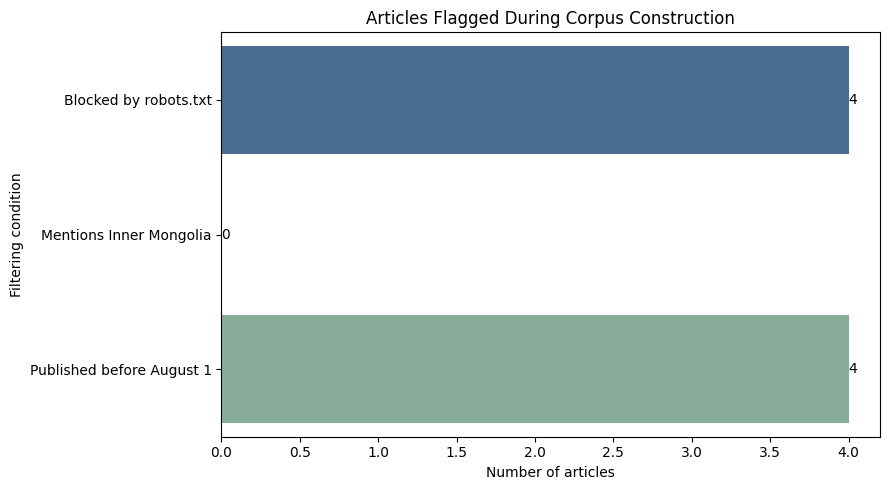

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

inner_mongolia = (
    articles["mentions_inner_mongolia"]
    .astype(str)
    .str.lower()
    .eq("true")
)

before_august = (
    articles["during_selected_period"]
    .astype(str)
    .str.lower()
    .eq("false")
)

condition_counts = pd.Series({
    "Blocked by robots.txt": (articles["word_count"] == 0).sum(),
    "Mentions Inner Mongolia": inner_mongolia.sum(),
    "Published before August 1": before_august.sum()
})

plt.figure(figsize=(9, 5))

sns.barplot(
    x=condition_counts.values,
    y=condition_counts.index,
    hue=condition_counts.index,
    palette=["#3B6F9C", "#E07A5F", "#81B29A"],
    legend=False
)

plt.xlabel("Number of articles")
plt.ylabel("Filtering condition")
plt.title("Articles Flagged During Corpus Construction")

for index, value in enumerate(condition_counts.values):
    plt.text(value, index, str(value), va="center")

plt.tight_layout()
plt.savefig("corpus_filtering_conditions.png", dpi=300)
plt.show()